In [1]:
# | default_exp dmd_data

# Build the Scaling Dataset

> We try make a dataset from a scaled network

In [2]:
from ast import literal_eval
from natsort import natsorted
import matplotlib.pyplot as plt
import matrepr
import numpy as np
from matrepr import mprint
from safetensors.torch import load_model, save_file

from learningdynamics.datasets import YinYangDataset
from learningdynamics.models import MLP
from learningdynamics.utils import (
    compute_model_accuracy,
    getActivation,
    safetensors_metadata_parser,
)
from collections import OrderedDict

In [3]:
# | export
import torch
import einops

In [4]:
# | hide
matrepr.params.title = True
matrepr.params.indices = False
matrepr.params.precision = 4
matrepr.cell_align = "left"

%matplotlib inline

#### Load Dataset

In [5]:
NUM_SAMPLES = 5_000
NUM_TRAJECTORIES = NUM_SAMPLES // 2  # Number of trajectories

In [6]:
# Build dataset
dataset = YinYangDataset(num_samples=NUM_SAMPLES, negative_label=False, seed=200)

In [7]:
## Override

# train_indices = torch.where(dataset.labels == 0)[0]
# test_indices = torch.where(dataset.labels == 1)[0]

# Randomly pick indices for training dataset
train_indices = np.random.choice(
    dataset.features.shape[0], size=NUM_TRAJECTORIES, replace=False
)


# Randomly pick indices for test dataset
test_indices = np.random.choice(
    np.setdiff1d(np.arange(NUM_SAMPLES), train_indices),
    size=int(NUM_SAMPLES - NUM_TRAJECTORIES),
    replace=False,
)

In [8]:
print("Train Indices")
mprint(train_indices)
print()
print("Test Indices")
mprint(test_indices)

Train Indices
<length=2500, 2500 'int64' elements, array>
[569, 2736, 4699, 2095, 384, 746, 4371, ..., 3962, 1129, 1994, 1383, 351, 4811]

Test Indices
<length=2500, 2500 'int64' elements, array>
[2331, 4250, 90, 4125, 4780, 3879, ..., 4285, 1880, 4484, 4622, 2675, 4105]


#### Load Original Model

In [9]:
# Load model
file_path = "../saved_weights/model.safetensors"
metadata = safetensors_metadata_parser(file_path=file_path)
model = MLP(
    config=literal_eval(metadata["config"]), nonlinearity=metadata["nonlinearity"]
)
_ = load_model(model, file_path, device="cuda:0")

In [10]:
_ = model.to("cpu")
print(f"Testing Accuracy: {compute_model_accuracy(model, dataset)}")

Testing Accuracy: 0.9760000109672546


In [11]:
model

MLP(
  (features): Sequential(
    (0): Linear(in_features=2, out_features=6, bias=True)
    (1): ReLU()
    (2): Linear(in_features=6, out_features=6, bias=True)
    (3): ReLU()
    (4): Linear(in_features=6, out_features=3, bias=True)
    (5): ReLU()
    (6): Linear(in_features=3, out_features=3, bias=True)
    (7): ReLU()
    (8): Linear(in_features=3, out_features=2, bias=True)
  )
)

In [12]:
LAYERS = [model.features[i] for i in (range(1, 4, 2))]

#### Load Scaled Model

In [13]:
# Load model
file_path = "../saved_weights/scaled_model.safetensors"
metadata = safetensors_metadata_parser(file_path=file_path)
scaled_model = MLP(
    config=literal_eval(metadata["config"]), nonlinearity=metadata["nonlinearity"]
)
_ = load_model(scaled_model, file_path, device="cuda:0")

In [14]:
_ = scaled_model.to("cpu")
print(f"Testing Accuracy: {compute_model_accuracy(scaled_model.to('cpu'), dataset)}")

Testing Accuracy: 0.9765999913215637


In [15]:
scaled_model

MLP(
  (features): Sequential(
    (0): Linear(in_features=2, out_features=6, bias=True)
    (1): ReLU()
    (2): Linear(in_features=6, out_features=6, bias=True)
    (3): ReLU()
    (4): Linear(in_features=6, out_features=6, bias=True)
    (5): ReLU()
    (6): Linear(in_features=6, out_features=6, bias=True)
    (7): ReLU()
    (8): Linear(in_features=6, out_features=6, bias=True)
    (9): ReLU()
    (10): Linear(in_features=6, out_features=6, bias=True)
    (11): ReLU()
    (12): Linear(in_features=6, out_features=6, bias=True)
    (13): ReLU()
    (14): Linear(in_features=6, out_features=6, bias=True)
    (15): ReLU()
    (16): Linear(in_features=6, out_features=6, bias=True)
    (17): ReLU()
    (18): Linear(in_features=6, out_features=6, bias=True)
    (19): ReLU()
    (20): Linear(in_features=6, out_features=6, bias=True)
    (21): ReLU()
    (22): Linear(in_features=6, out_features=6, bias=True)
    (23): ReLU()
    (24): Linear(in_features=6, out_features=6, bias=True)
    (25)

In [16]:
NUM_STATES = 6

In [17]:
NUM_ITERATIONS = int(metadata["added_layers"]) + 2
SCALED_LAYERS = [scaled_model.features[i] for i in (range(1, NUM_ITERATIONS * 2, 2))]

#### Get activations

In [18]:
hooks = []

# Dictionary to store activations
activation_dict = {}
scaled_activation_dict = {}

# Register the hooks
for idx, layer in enumerate(LAYERS):
    hooks.append(
        layer.register_forward_hook(getActivation(f"layer_{idx}", activation_dict))
    )

for idx, scaled_layer in enumerate(SCALED_LAYERS):
    hooks.append(
        scaled_layer.register_forward_hook(
            getActivation(f"scaled_layer_{idx}", scaled_activation_dict)
        )
    )

_ = model(dataset.features)
_ = scaled_model(dataset.features)

# Remove hook
for hook in hooks:
    hook.remove()

In [19]:
def collect_timestep_tensor(dict, shuffle=False):
    # sorted_dict = OrderedDict(natsorted(dict.items()))
    sorted_dict = dict
    values = list(sorted_dict.values())
    values_tensor = torch.stack(values)
    if shuffle:
        idx = torch.randperm(values_tensor.shape[1])
        values_tensor = values_tensor[:, idx, :]
    return values_tensor

#### Visualizing Trajectory

In [20]:
SAMPLE = 0

In [21]:
t = np.linspace(0, 1, 2)
states = collect_timestep_tensor(activation_dict)[:, SAMPLE, :].T

ts = np.linspace(0, 1, NUM_ITERATIONS)
scaled_states = collect_timestep_tensor(scaled_activation_dict)[:, SAMPLE, :].T

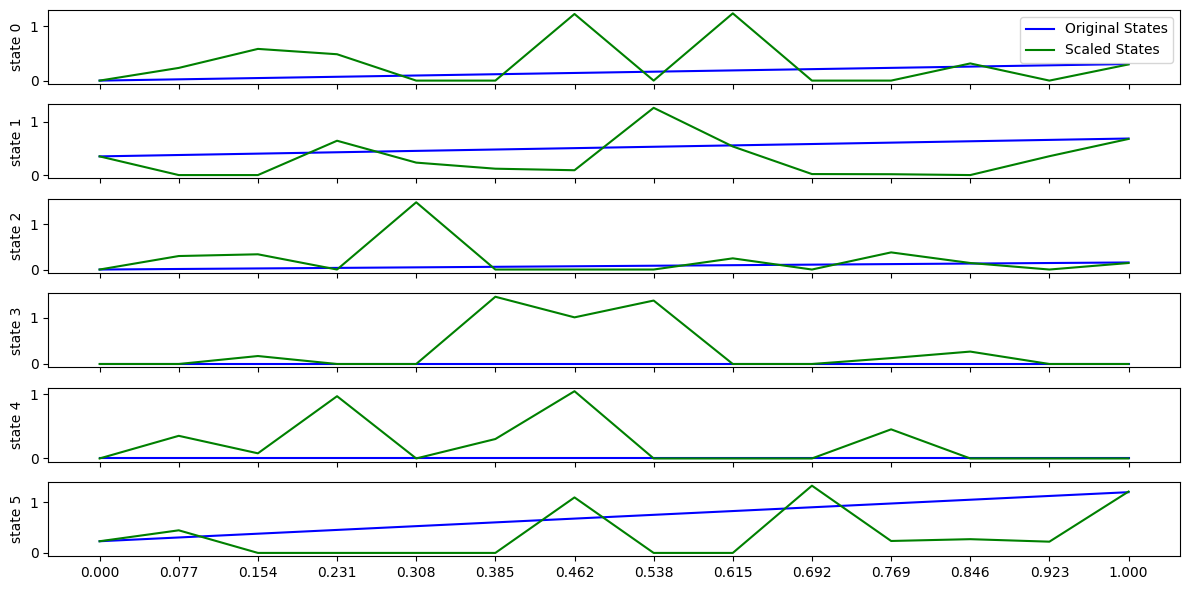

In [32]:
fig, axs = plt.subplots(6, 1, sharex=True, tight_layout=True, figsize=(12, 6))

for state_idx in range(0, NUM_STATES):
    axs[state_idx].plot(
        t, states[state_idx, :], "-", color="b", label="Original States"
    )
    axs[state_idx].plot(
        ts, scaled_states[state_idx, :], "-", color="g", label="Scaled States"
    )
    axs[state_idx].set(ylabel=f"state {state_idx}")

axs[-1].set_xticks(ts)
# axs[-1].set_xticklabels(ts)

axs[0].legend()

In [23]:
metadata_dict = {
    "NUM_STATES": str(NUM_STATES),
    "NUM_TRAJECTORIES": str(NUM_TRAJECTORIES),
    "NUM_ITERATIONS": str(NUM_ITERATIONS),
}

save_file(
    {
        "train_states": collect_timestep_tensor(scaled_activation_dict)[
            :, train_indices, :
        ].contiguous(),
        "test_states": collect_timestep_tensor(scaled_activation_dict, shuffle=True)[
            :, test_indices, :
        ].contiguous(),
    },
    "../saved_weights/states.safetensors",
    metadata=metadata_dict,
)

#### Reshaping dataset

In [24]:
# | export
def reshape_interleave_time(
    x: torch.Tensor,  # Input tensor
):
    return einops.rearrange(x, "i t s -> s (i t)")

In [25]:
# | export
def reshape_interleave_state(
    x: torch.Tensor,  # Input tensor
):
    return einops.rearrange(x, "i t s -> (s t) i")

In [26]:
# | export
def reshape_append_time(
    x: torch.Tensor,  # Input tensor
):
    return einops.rearrange(x, "i t s -> s (t i)")

In [27]:
# | export
def reshape_append_state(
    x: torch.Tensor,  # Input tensor
):
    return einops.rearrange(x, "i t s -> (t s) i")